# 01 - Exploratory Data Analysis

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 

sns.set_theme(style='whitegrid')
pd.set_option("display.max_columns", 50)

In [2]:
from src.data.loader import SessionDataLoader
from src.config.settings import get_settings

settings = get_settings()
df = SessionDataLoader(settings=settings).load()
df.shape

2026-08-10 14:24:08 | INFO     | src.data.loader | Loaded 12000 rows, 18 columns from C:\Desktop\Inernships\Projects\E-Commerce Purchase Intent Prediction using Explainable AI\dataset\ecommerce_sessions.csv
2026-08-10 14:24:08 | INFO     | src.data.loader | Schema validation passed.


(12000, 18)

# Overall conversion rate

Conversion rate: 15.72%


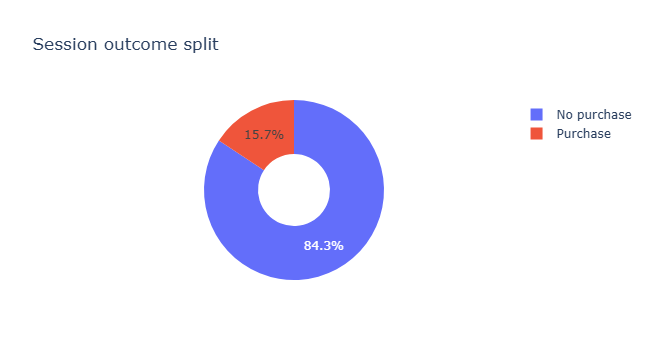

In [4]:
conv_rate = df['Converted'].mean()
print(f'Conversion rate: {conv_rate:.2%}')
fig = px.pie(df, names=df['Converted'].map({0: 'No purchase', 1: 'Purchase'}),
            title='Session outcome split', hole=0.4)
fig.show()

# PageValues: buyers vs non-buyers

2026-08-10 14:31:22 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-10 14:31:22 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


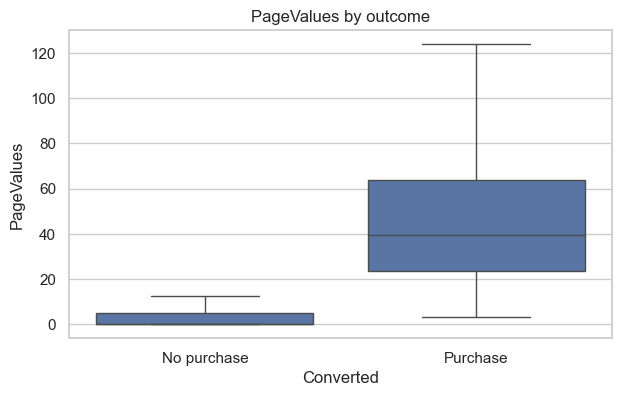

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='Converted', y='PageValues', ax=ax, showfliers=False)
ax.set_xticklabels(['No purchase', 'Purchase'])
ax.set_title('PageValues by outcome')
plt.show()

# Seasonality

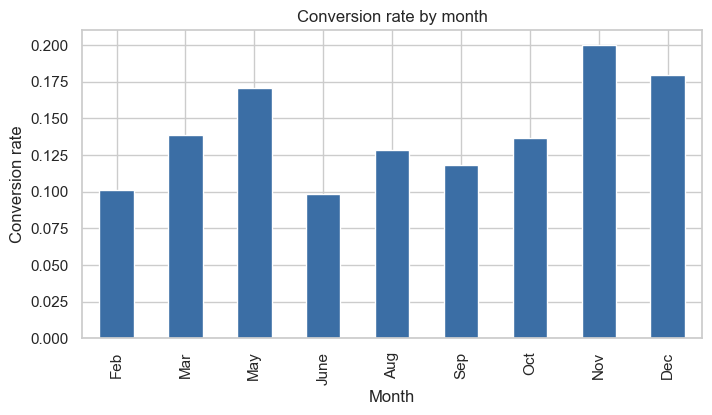

In [9]:
month_order = ['Feb', 'Mar', 'May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly = df.groupby('Month')['Converted'].mean().reindex(
    [m for m in month_order if m in df['Month'].unique()])
fig, ax = plt.subplots(figsize=(8, 4))
monthly.plot(kind='bar', ax=ax, color='#3b6ea5')
ax.set_ylabel('Conversion rate')
ax.set_title('Conversion rate by month')
plt.show()

# Visitor type

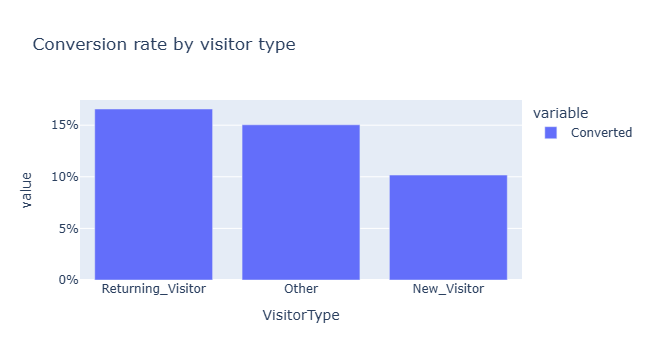

In [10]:
visitor_conv = df.groupby('VisitorType')['Converted'].mean().sort_values(ascending=False)
fig = px.bar(visitor_conv, title='Conversion rate by visitor type')
fig.update_yaxes(tickformat='.0%')
fig.show()

# Engagement vs ecit behaviour

2026-08-10 14:47:50 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-10 14:47:51 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-10 14:47:51 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-10 14:47:51 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


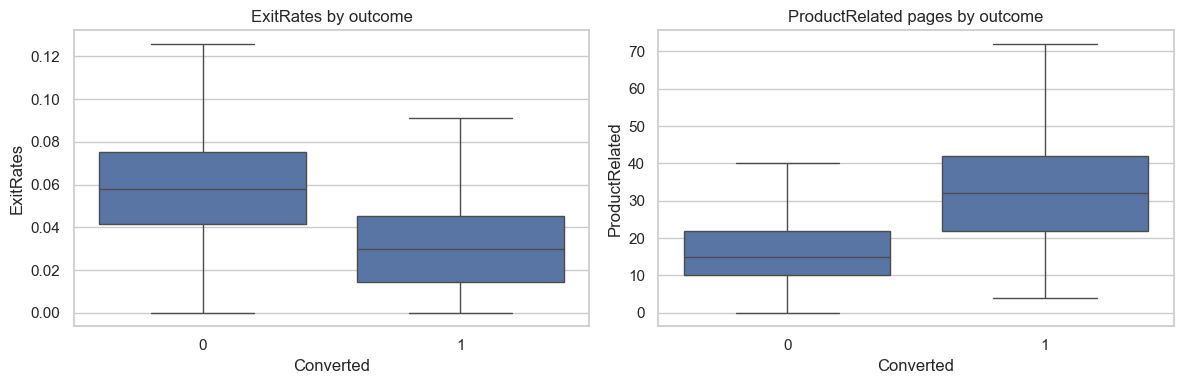

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='Converted', y='ExitRates', ax=axes[0], showfliers=False)
sns.boxplot(data=df, x='Converted', y='ProductRelated', ax=axes[1], showfliers=False)
axes[0].set_title('ExitRates by outcome')
axes[1].set_title('ProductRelated pages by outcome')
plt.tight_layout()
plt.show()

# Correlation structure

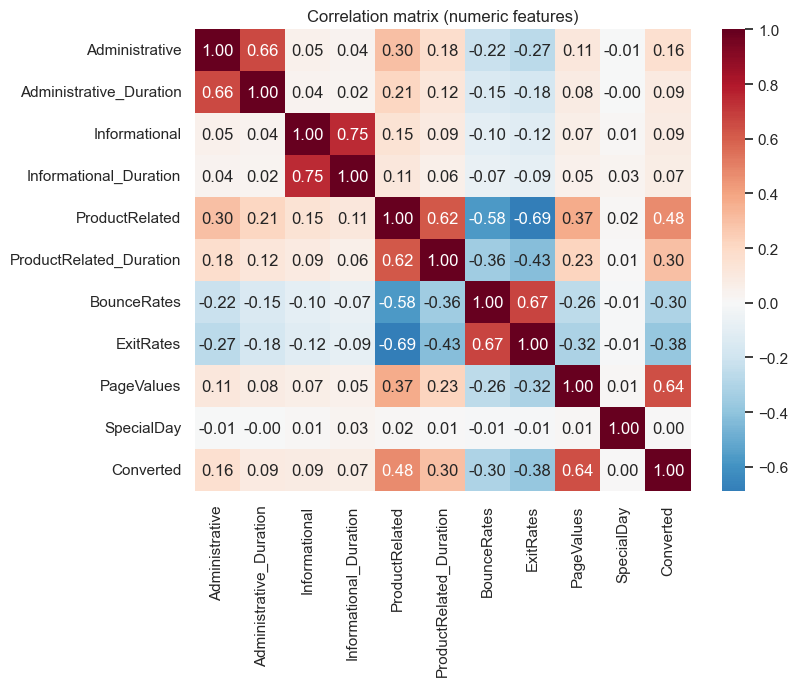

In [13]:
numeric_cols = ['Administrative','Administrative_Duration','Informational',
                'Informational_Duration','ProductRelated','ProductRelated_Duration',
                'BounceRates','ExitRates','PageValues','SpecialDay','Converted']
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
plt.title('Correlation matrix (numeric features)')
plt.show()